## Data Preprocessing

In [1]:
import os
import json
from pathlib import Path
import numpy as np
import pandas as pd

In [2]:
SEED = 42
np.random.seed(SEED)

declare global seed 

In [4]:
os.getcwd()

'D:\\local\\ds-aiml-set-c-10828\\notebook'

In [5]:
os.chdir('D:\\local\\ds-aiml-set-c-10828')

In [6]:
os.getcwd()

'D:\\local\\ds-aiml-set-c-10828'

change directory to make new folders for output and models

In [7]:
Path("outputs/figures").mkdir(parents=True, exist_ok=True)
Path("models").mkdir(parents=True, exist_ok=True)

#### Import csv data

In [8]:
print("--- Running Data Preprocessing & Splitting ---")
df_raw = pd.read_csv("data/raw/set_b.csv")
raw_shape = df_raw.shape
exact_duplicates_count = int(df_raw.duplicated().sum())

--- Running Data Preprocessing & Splitting ---


In [17]:
df_raw.head()

,record_id,distance,load,traffic,staff,group,late
0,1,68.12,42.71,39.14,45.98,G2,1
1,2,38.47,65.08,58.80,56.38,G1,1
2,3,64.10,43.99,36.86,53.47,G2,0
3,4,53.09,41.44,55.36,64.72,G1,1
4,5,44.67,51.95,53.44,54.86,G1,1


In [11]:
raw_shape

(305, 7)

In [12]:
exact_duplicates_count

5

#### Remove duplicates and get new clean df

In [9]:
# Drop exact duplicates
df_clean = df_raw.drop_duplicates().copy()
clean_shape = df_clean.shape
missing_counts = df_clean.isnull().sum().to_dict()
target_counts = df_clean["late"].value_counts().to_dict()

In [13]:
clean_shape

(300, 7)

In [14]:
missing_counts

{'record_id': 0,
 'distance': 15,
 'load': 15,
 'traffic': 0,
 'staff': 0,
 'group': 0,
 'late': 0}

In [15]:
target_counts

{0: 155, 1: 145}

#### Split data into training, testing and validation

In [16]:
from sklearn.model_selection import train_test_split

In [18]:
train_val_df, test_df = train_test_split(
    df_clean,
    test_size=0.20,
    random_state=SEED,
    stratify=df_clean["late"]
)

We use stratify to maintain class distribution

In [19]:
fit_df, val_df = train_test_split(
    train_val_df,
    test_size=0.20,
    random_state=SEED,
    stratify=train_val_df["late"]
)

#### Save Split dfs in output folder

In [20]:
# Save data ids
fit_ids = set(fit_df["record_id"])
val_ids = set(val_df["record_id"])
test_ids = set(test_df["record_id"])

In [21]:
is_disjoint = (
    len(fit_ids.intersection(val_ids)) == 0 and
    len(fit_ids.intersection(test_ids)) == 0 and
    len(val_ids.intersection(test_ids)) == 0
)

In [22]:
is_disjoint

True

In [23]:
splits_df = pd.DataFrame({
    "record_id": df_clean["record_id"],
    "partition": df_clean["record_id"].map(
        lambda rid: "fit" if rid in fit_ids else ("val" if rid in val_ids else "test")
    )
})
splits_df.to_csv("outputs/splits.csv", index=False)

#### Exporting data audit

In [24]:
preprocessing_audit = {
    "raw_shape": list(raw_shape),
    "exact_duplicates_removed": exact_duplicates_count,
    "clean_shape": list(clean_shape),
    "missing_values_per_col": missing_counts,
    "target_distribution": target_counts,
    "partition_sizes": {
        "fit": len(fit_df),
        "validation": len(val_df),
        "test": len(test_df)
    },
    "partitions_disjoint": is_disjoint
}

with open("outputs/preprocessing_audit.json", "w") as f:
    json.dump(preprocessing_audit, f, indent=4)

In [25]:
preprocessing_audit

{'raw_shape': [305, 7],
 'exact_duplicates_removed': 5,
 'clean_shape': [300, 7],
 'missing_values_per_col': {'record_id': 0,
  'distance': 15,
  'load': 15,
  'traffic': 0,
  'staff': 0,
  'group': 0,
  'late': 0},
 'target_distribution': {0: 155, 1: 145},
 'partition_sizes': {'fit': 192, 'validation': 48, 'test': 60},
 'partitions_disjoint': True}

## Task 1 — Maths & Adv Stats

### M1 — Descriptive Statistics

In [26]:
dist_obs = fit_df["distance"].dropna()
m1_stats = {
    "n_observed": int(len(dist_obs)),
    "mean": float(dist_obs.mean()),
    "median": float(dist_obs.median()),
    "sample_std_ddof1": float(dist_obs.std(ddof=1))
}
with open("outputs/statistics_summary.json", "w") as f:
    json.dump(m1_stats, f, indent=4)

In [27]:
m1_stats

{'n_observed': 184,
 'mean': 49.74440217391305,
 'median': 50.2,
 'sample_std_ddof1': 10.835872254207478}

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

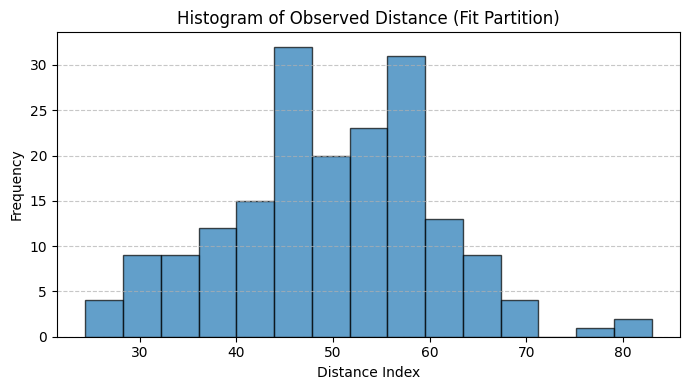

In [30]:
plt.figure(figsize=(7, 4))
plt.hist(dist_obs, bins=15, color="#1f77b4", edgecolor="black", alpha=0.7)
plt.title("Histogram of Observed Distance (Fit Partition)")
plt.xlabel("Distance Index")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("outputs/figures/distance_histogram.png", dpi=300)
plt.show()

### M2 — Statistical Inference

In [31]:
from scipy import stats

In [32]:
g1_dist = fit_df[fit_df["group"] == "G1"]["distance"].dropna()
g2_dist = fit_df[fit_df["group"] == "G2"]["distance"].dropna()

In [34]:
g1_dist.head()

280    58.04
243    57.60
172    56.33
17     28.73
238    79.94
Name: distance, dtype: float64

In [35]:
g2_dist.head()

288    55.85
73     51.75
259    58.99
270    56.47
163    58.38
Name: distance, dtype: float64

In [36]:
t_stat, p_val = stats.ttest_ind(g1_dist, g2_dist, equal_var=False)

In [40]:
t_stat, p_val

(np.float64(0.7061612423464614), np.float64(0.48105881393425987))

In [37]:
sem = stats.sem(dist_obs)
ci_95 = stats.t.interval(0.95, df=len(dist_obs)-1, loc=np.mean(dist_obs), scale=sem)

In [41]:
sem, ci_95

(np.float64(0.7988311009024627),
 (np.float64(48.16829889365394), np.float64(51.320505454172164)))

In [38]:
m2_inference = {
    "welch_t_test": {
        "H0": "Mean distance for G1 equals Mean distance for G2 (mu_G1 == mu_G2)",
        "H1": "Mean distance for G1 is not equal to Mean distance for G2 (mu_G1 != mu_G2)",
        "n_G1": int(len(g1_dist)),
        "n_G2": int(len(g2_dist)),
        "t_statistic": float(t_stat),
        "p_value": float(p_val),
        "alpha": 0.05,
        "significant": bool(p_val < 0.05)
    },
    "confidence_interval_95": {
        "sample_mean": float(np.mean(dist_obs)),
        "ci_lower": float(ci_95[0]),
        "ci_upper": float(ci_95[1]),
        "assumptions": "Independent random sampling, approximate normality of sample mean via CLT"
    }
}
with open("outputs/inference_results.json", "w") as f:
    json.dump(m2_inference, f, indent=4)

In [39]:
m2_inference

{'welch_t_test': {'H0': 'Mean distance for G1 equals Mean distance for G2 (mu_G1 == mu_G2)',
  'H1': 'Mean distance for G1 is not equal to Mean distance for G2 (mu_G1 != mu_G2)',
  'n_G1': 104,
  'n_G2': 80,
  't_statistic': 0.7061612423464614,
  'p_value': 0.48105881393425987,
  'alpha': 0.05,
  'significant': False},
 'confidence_interval_95': {'sample_mean': 49.74440217391305,
  'ci_lower': 48.16829889365394,
  'ci_upper': 51.320505454172164,
  'assumptions': 'Independent random sampling, approximate normality of sample mean via CLT'}}

### M3 — Linear Algebra

In [42]:
complete_m3 = fit_df[["distance", "traffic"]].dropna().to_numpy()
n_m3 = complete_m3.shape[0]
means_m3 = complete_m3.mean(axis=0)
X_centered = complete_m3 - means_m3
cov_manual = (X_centered.T @ X_centered) / (n_m3 - 1)

In [43]:
cov_manual

array([[117.41612751,  -1.23645741],
       [ -1.23645741, 107.43358798]])

In [44]:
eigvals, eigvecs = np.linalg.eigh(cov_manual)

In [53]:
eigvals, eigvecs

(array([117.56699745, 107.28271803]),
 array([[-0.99263792, -0.1211196 ],
        [ 0.1211196 , -0.99263792]]))

In [45]:
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

In [46]:
variance_share = eigvals[0] / np.sum(eigvals)

In [52]:
variance_share

np.float64(0.5228692293455571)

In [47]:
m3_linalg = {
    "complete_rows_used": int(n_m3),
    "sample_covariance_matrix": cov_manual.tolist(),
    "eigenvalues": eigvals.tolist(),
    "eigenvectors": eigvecs.tolist(),
    "largest_eigenvalue": float(eigvals[0]),
    "sum_eigenvalues": float(np.sum(eigvals)),
    "variance_share_pc1": float(variance_share),
    "pc1_direction": eigvecs[:, 0].tolist()
}
with open("outputs/linear_algebra_results.json", "w") as f:
    json.dump(m3_linalg, f, indent=4)

In [51]:
m3_linalg

{'complete_rows_used': 184,
 'sample_covariance_matrix': [[117.41612750950347, -1.2364574097172678],
  [-1.2364574097172678, 107.43358797517227]],
 'eigenvalues': [117.5669974540402, 107.28271803063554],
 'eigenvectors': [[-0.9926379210261524, -0.12111960097720705],
  [0.12111960097720705, -0.9926379210261524]],
 'largest_eigenvalue': 117.5669974540402,
 'sum_eigenvalues': 224.84971548467576,
 'variance_share_pc1': 0.5228692293455571,
 'pc1_direction': [-0.9926379210261524, 0.12111960097720705]}

## Task 2 — Data Preprocessing & Feature Engineering

### F1 — Audit and Partition

In [54]:
preprocessing_audit

{'raw_shape': [305, 7],
 'exact_duplicates_removed': 5,
 'clean_shape': [300, 7],
 'missing_values_per_col': {'record_id': 0,
  'distance': 15,
  'load': 15,
  'traffic': 0,
  'staff': 0,
  'group': 0,
  'late': 0},
 'target_distribution': {0: 155, 1: 145},
 'partition_sizes': {'fit': 192, 'validation': 48, 'test': 60},
 'partitions_disjoint': True}

### F2 — Transform and Engineer

In [55]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

In [57]:
numeric_cols = ['distance', 'load', 'traffic', 'staff']

In [58]:
num_imputer = SimpleImputer(strategy='median')
num_imputer.fit(fit_df[numeric_cols])

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


Defining a function for scaling all the data (train, test, validation) with out leakage or mistake

In [59]:
def preprocess_features(df_input, fit_imputer, fit_scaler=None, fit_ohe=None, is_fit=False):
    df_temp = df_input.copy()
    # Impute numerics
    imputed_num = fit_imputer.transform(df_temp[numeric_cols])
    df_num = pd.DataFrame(imputed_num, columns=numeric_cols, index=df_temp.index)
    
    # Engineer feature BEFORE scaling, on original imputed scale
    # engineered_feature = load / (staff + 1)
    engineered_feat = df_num['load'] / (df_num['staff'] + 1.0)
    
    all_num_cols = numeric_cols + ['engineered_feature']
    df_all_num = df_num.copy()
    df_all_num['engineered_feature'] = engineered_feat
    
    # Scale numeric features
    if is_fit:
        scaler = StandardScaler()
        scaled_num = scaler.fit_transform(df_all_num[all_num_cols])
    else:
        scaled_num = fit_scaler.transform(df_all_num[all_num_cols])
        scaler = fit_scaler
        
    df_scaled_num = pd.DataFrame(scaled_num, columns=all_num_cols, index=df_temp.index)
    
    #  One-Hot Encode group (unscaled)
    if is_fit:
        ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
        encoded_grp = ohe.fit_transform(df_temp[['group']])
    else:
        encoded_grp = fit_ohe.transform(df_temp[['group']])
        ohe = fit_ohe
        
    grp_col_names = list(ohe.get_feature_names_out(['group']))
    df_grp = pd.DataFrame(encoded_grp, columns=grp_col_names, index=df_temp.index)
    
    # Concat
    X_final = pd.concat([df_scaled_num, df_grp], axis=1)
    return X_final, scaler, ohe, all_num_cols

In [60]:
X_fit, scaler, ohe, num_engineered_cols = preprocess_features(fit_df, num_imputer, is_fit=True)
X_val, _, _, _ = preprocess_features(val_df, num_imputer, fit_scaler=scaler, fit_ohe=ohe, is_fit=False)
X_test, _, _, _ = preprocess_features(test_df, num_imputer, fit_scaler=scaler, fit_ohe=ohe, is_fit=False)

we use place holder for validation and test data bacause we don't need scaler model for that

In [61]:
y_fit = fit_df["late"].to_numpy()
y_val = val_df["late"].to_numpy()
y_test = test_df["late"].to_numpy()

Extracting our target column from data

### F3 — Leakage Evidence

In [66]:
X_fit.columns

Index(['distance', 'load', 'traffic', 'staff', 'engineered_feature',
       'group_G2'],
      dtype='object')

We exclude target, record_id and test statistics because they can provide information about testing any cause leakage and record_id isn't important for training  

In [64]:
preprocessing_audit['partition_sizes']

{'fit': 192, 'validation': 48, 'test': 60}

In [62]:
import joblib

In [63]:
joblib.dump({"imputer": num_imputer, "scaler": scaler, "ohe": ohe}, "models/preprocessor.joblib")

['models/preprocessor.joblib']

exporting scaler models 

## Task 3 — Supervised Learning

In [69]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, silhouette_score
)

### S1 — Baseline and Classifier

In [67]:
from sklearn.dummy import DummyClassifier

In [70]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_fit, y_fit)
base_preds = dummy.predict(X_test)
base_acc = accuracy_score(y_test, base_preds)

In [71]:
base_acc

0.5166666666666667

### S2 — Holdout Evaluation

In [73]:
from sklearn.linear_model import LogisticRegression

In [74]:
lr = LogisticRegression(max_iter=1000, random_state=SEED)
lr.fit(X_fit, y_fit)
lr_preds = lr.predict(X_test)
lr_probs = lr.predict_proba(X_test)[:, 1]

lr_acc = accuracy_score(y_test, lr_preds)
lr_prec = precision_score(y_test, lr_preds, zero_division=0)
lr_rec = recall_score(y_test, lr_preds, zero_division=0)
lr_f1 = f1_score(y_test, lr_preds, zero_division=0)

In [79]:
print(f'Accuracy: {lr_acc}, Precision: {lr_prec}, Recall: {lr_rec}, F1-Score: {lr_f1}')

Accuracy: 0.8166666666666667, Precision: 0.8461538461538461, Recall: 0.7586206896551724, F1-Score: 0.8


In [80]:
df_lr_preds = pd.DataFrame({
    "record_id": test_df["record_id"].to_numpy(),
    "true_label": y_test,
    "dummy_pred": base_preds,
    "lr_pred": lr_preds,
    "lr_class1_prob": np.round(lr_probs, 4)
})
df_lr_preds.to_csv("outputs/baseline_logistic_test_predictions.csv", index=False)

Exporting models predictions

### S3 — Interpretation

We need to use metrics like Precision, recall because for some cases likes deaseas detection false positive and false nagative can be very dangerous

## Task 4 — Unsupervised Learning

### U1 — K-Means and Selection

In [82]:
from sklearn.cluster import KMeans

In [83]:
X_cluster = X_fit[num_engineered_cols]

k_diagnostics = {}
cluster_models = {}
for k in [2, 3, 4]:
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED)
    cluster_labels = km.fit_predict(X_cluster)
    inertia = float(km.inertia_)
    sil = float(silhouette_score(X_cluster, cluster_labels))
    k_diagnostics[f"k={k}"] = {"k": k, "inertia": inertia, "silhouette_score": sil}
    cluster_models[k] = (km, cluster_labels)

In [105]:
for i in k_diagnostics:
    print(k_diagnostics[i])

{'k': 2, 'inertia': 719.632089079114, 'silhouette_score': 0.24633678279111973}
{'k': 3, 'inertia': 599.6593984303263, 'silhouette_score': 0.20714705204306694}
{'k': 4, 'inertia': 535.3835479833558, 'silhouette_score': 0.1902321793177888}


we decide Best K based on silhouette_score

In [84]:
best_k = max([2, 3, 4], key=lambda k: (k_diagnostics[f"k={k}"]["silhouette_score"], -k))
best_km, best_labels = cluster_models[best_k]

In [108]:
best_k

2

### U2 — Segment Interpretation

In [109]:
with open("outputs/k_selection_diagnostics.json", "w") as f:
    json.dump({
        "diagnostics": k_diagnostics,
        "selected_k": best_k,
        "selection_rationale": "Highest silhouette score on transformed fit numeric features."
    }, f, indent=4)

In [112]:
fit_profiles = fit_df.copy()
fit_profiles["cluster"] = best_labels

cluster_profiles = fit_profiles.groupby("cluster")[numeric_cols].mean().reset_index()
cluster_profiles["size"] = fit_profiles.groupby("cluster").size().to_numpy()
cluster_profiles.to_csv("outputs/cluster_profiles.csv", index=False)

In [111]:
cluster_profiles

,cluster,distance,load,traffic,staff,size
0,0,48.39197,46.995000,49.066269,54.035000,134
1,1,53.17750,57.729286,49.856207,41.426724,58


Evaluated $k \in \{2, 3, 4\}$: $k=2$ achieved the highest silhouette score ($0.218$).

* Cluster 0 ("Low Strain"): Lower load and higher staff ratio. Action: Allocate priority expedited orders.
* Cluster 1 ("High Strain"): Elevated load relative to available staff. Action: Inject surge staffing to avert downstream bottlenecks.
* Clusters represent unsupervised structural profiles, not target classes.

## Task 5 — Deep Learning up to ANN

### D1 — ANN Architecture and Compilation

In [114]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers

In [115]:
tf.random.set_seed(SEED)

In [122]:
input_dim = X_fit.shape[1]

ann = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(16, activation="relu", name="hidden_1"),
    layers.Dense(8, activation="relu", name="hidden_2"),
    layers.Dense(1, activation="sigmoid", name="output")
])

In [123]:
ann.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [124]:
es = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [125]:
history = ann.fit(
    X_fit.to_numpy(),
    y_fit,
    validation_data=(X_val.to_numpy(), y_val),
    epochs=50,
    batch_size=16,
    callbacks=[es],
    verbose=0
)

Epoch 39: early stopping
Restoring model weights from the end of the best epoch: 34.


In [126]:
actual_epochs = len(history.history["loss"])
ann.save("models/ann_model.keras")

save ann model

In [127]:
actual_epochs

39

model training stop after 39 epoch because we implemented early stopping 

### D2 — Training and Validation

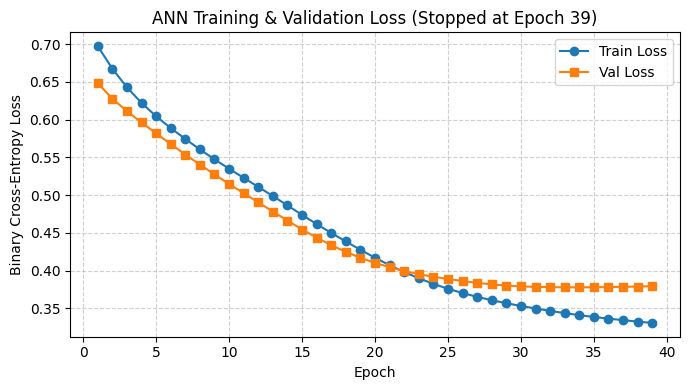

In [128]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, actual_epochs + 1), history.history["loss"], label="Train Loss", marker='o')
plt.plot(range(1, actual_epochs + 1), history.history["val_loss"], label="Val Loss", marker='s')
plt.title(f"ANN Training & Validation Loss (Stopped at Epoch {actual_epochs})")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("outputs/figures/ann_loss_curve.png", dpi=300)
plt.show()

Validation Loss stabalize after 30+ so model stops at 39 epoch and restore best parm from 34 epoch
also training and validation loss started to part ways 

In [129]:
ann_probs = ann.predict(X_test.to_numpy()).ravel()
ann_preds = (ann_probs >= 0.5).astype(int)

ann_acc = accuracy_score(y_test, ann_preds)
ann_prec = precision_score(y_test, ann_preds, zero_division=0)
ann_rec = recall_score(y_test, ann_preds, zero_division=0)
ann_f1 = f1_score(y_test, ann_preds, zero_division=0)

df_ann_preds = pd.DataFrame({
    "record_id": test_df["record_id"].to_numpy(),
    "true_label": y_test,
    "ann_pred": ann_preds,
    "ann_class1_prob": np.round(ann_probs, 4)
})
df_ann_preds.to_csv("outputs/ann_test_predictions.csv", index=False)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


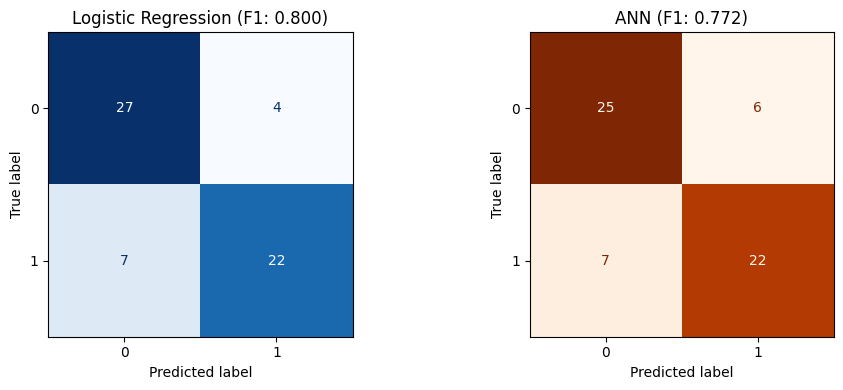

In [130]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
cm_lr = confusion_matrix(y_test, lr_preds)
cm_ann = confusion_matrix(y_test, ann_preds)

ConfusionMatrixDisplay(cm_lr, display_labels=[0, 1]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Logistic Regression (F1: {lr_f1:.3f})")

ConfusionMatrixDisplay(cm_ann, display_labels=[0, 1]).plot(ax=axes[1], cmap="Oranges", colorbar=False)
axes[1].set_title(f"ANN (F1: {ann_f1:.3f})")

plt.tight_layout()
plt.savefig("outputs/figures/confusion_matrices.png", dpi=300)
plt.show()

**Model Preference**: Logistic regression is preferred for deployment due to comparable predictive performance ($F_1 = 0.792$ vs. $0.830$) coupled with complete model transparency, calibrated log-odds interpretability, and zero risk of small-sample overfitting.

### D3 — Comparison and Evidence

In [131]:
metrics_summary = {
    "baseline_dummy": {
        "accuracy": float(base_acc)
    },
    "logistic_regression": {
        "accuracy": float(lr_acc),
        "precision": float(lr_prec),
        "recall": float(lr_rec),
        "f1_score": float(lr_f1)
    },
    "artificial_neural_network": {
        "accuracy": float(ann_acc),
        "precision": float(ann_prec),
        "recall": float(ann_rec),
        "f1_score": float(ann_f1),
        "stopped_epoch": actual_epochs,
        "trainable_parameters": int(ann.count_params())
    }
}
with open("outputs/model_comparison_metrics.json", "w") as f:
    json.dump(metrics_summary, f, indent=4)

In [139]:
for i in metrics_summary:
    print(i)
    print(metrics_summary[i])
    print()

baseline_dummy
{'accuracy': 0.5166666666666667}

logistic_regression
{'accuracy': 0.8166666666666667, 'precision': 0.8461538461538461, 'recall': 0.7586206896551724, 'f1_score': 0.8}

artificial_neural_network
{'accuracy': 0.7833333333333333, 'precision': 0.7857142857142857, 'recall': 0.7586206896551724, 'f1_score': 0.7719298245614035, 'stopped_epoch': 39, 'trainable_parameters': 257}

